# Vol-Targeted SMA Crossover, Multi-Asset

Synthesis of the prior three notebooks:

1. SMA 50/200 generates a binary trend signal (long / flat).
2. Volatility targeting modulates the *size* of the long position so that risk is roughly constant when in the trade.
3. Apply across SPY, QQQ, IWM, XLK, XLE — and compare four variants per asset:
    - Buy & Hold
    - Vanilla SMA 50/200 (binary)
    - Vol-targeted (always on)
    - **Vol-targeted SMA** (sized trend)

**Hypothesis:** sized trend should improve Sharpe vs vanilla SMA (size = quality control) while keeping the drawdown reduction that pure vol-targeting does not provide on its own.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

TRADING_DAYS = 252
START = '2010-01-01'
END = '2026-05-08'
TICKERS = ['SPY', 'QQQ', 'IWM', 'XLK', 'XLE']
FAST, SLOW = 50, 200
TARGET_VOL = 0.15
VOL_LOOKBACK = 20
MAX_LEVERAGE = 2.0
COST_BPS = 5

## 1. Data

In [2]:
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'] if 'Close' in raw.columns.get_level_values(0) else raw
prices = prices.dropna()
print(f'Rows: {len(prices)}  Range: {prices.index.min().date()} to {prices.index.max().date()}')
prices.head()

Rows: 4111  Range: 2010-01-04 to 2026-05-07


Ticker,IWM,QQQ,SPY,XLE,XLK
Date,,,,,
2010-01-04,51.366550,40.290794,84.796387,17.268267,9.378782
2010-01-05,51.189941,40.290794,85.020851,17.409210,9.366692
2010-01-06,51.141762,40.047749,85.080704,17.617685,9.261897
2010-01-07,51.519093,40.073780,85.439873,17.591257,9.225627
2010-01-08,51.800106,40.403610,85.724182,17.705780,9.286082


## 2. Strategy builders

In [3]:
def signal_sma(close, fast=50, slow=200):
    sf = close.rolling(fast).mean()
    ss = close.rolling(slow).mean()
    return (sf > ss).astype(float)

def vol_target_sizing(returns, target_vol=0.15, lookback=20, max_lev=2.0):
    rv = returns.rolling(lookback).std() * np.sqrt(TRADING_DAYS)
    return (target_vol / rv).clip(upper=max_lev).fillna(0)

def backtest(close, position, cost_bps=5):
    df = pd.DataFrame({'close': close})
    df['ret'] = df['close'].pct_change().fillna(0)
    # shift position by 1 to avoid lookahead
    df['pos'] = position.shift(1).fillna(0)
    df['exp_change'] = df['pos'].diff().abs().fillna(0)
    df['strat_ret'] = df['ret'] * df['pos'] - (cost_bps / 10000.0) * df['exp_change']
    df['equity'] = (1 + df['strat_ret']).cumprod()
    return df

def perf(returns, equity):
    years = len(returns) / TRADING_DAYS
    cagr = equity.iloc[-1] ** (1 / years) - 1 if equity.iloc[-1] > 0 else -1
    sharpe = (returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS) if returns.std() > 0 else 0
    rv = returns.std() * np.sqrt(TRADING_DAYS)
    dd = (equity / equity.cummax() - 1).min()
    calmar = cagr / abs(dd) if dd != 0 else np.nan
    return {'cagr': cagr, 'realized_vol': rv, 'sharpe': sharpe, 'max_dd': dd, 'calmar': calmar}

## 3. Run all four strategies on each ticker

In [4]:
all_results = []
equity_curves = {}

for ticker in TICKERS:
    close = prices[ticker]
    rets = close.pct_change().fillna(0)

    # 1. Buy & Hold
    bh = backtest(close, pd.Series(1.0, index=close.index), cost_bps=0)
    all_results.append({'ticker': ticker, 'strategy': 'buy_hold', **perf(bh['strat_ret'], bh['equity'])})

    # 2. Vanilla SMA
    sma_pos = signal_sma(close, FAST, SLOW)
    sma = backtest(close, sma_pos, COST_BPS)
    all_results.append({'ticker': ticker, 'strategy': 'sma_vanilla', **perf(sma['strat_ret'], sma['equity'])})

    # 3. Vol-targeted (always on)
    vt_pos = vol_target_sizing(rets, TARGET_VOL, VOL_LOOKBACK, MAX_LEVERAGE)
    vt = backtest(close, vt_pos, COST_BPS)
    all_results.append({'ticker': ticker, 'strategy': 'vol_target_only', **perf(vt['strat_ret'], vt['equity'])})

    # 4. Vol-targeted SMA (sized trend)
    sized_pos = sma_pos * vol_target_sizing(rets, TARGET_VOL, VOL_LOOKBACK, MAX_LEVERAGE)
    sized = backtest(close, sized_pos, COST_BPS)
    all_results.append({'ticker': ticker, 'strategy': 'vt_sma', **perf(sized['strat_ret'], sized['equity'])})

    equity_curves[ticker] = {
        'buy_hold': bh['equity'],
        'sma_vanilla': sma['equity'],
        'vol_target_only': vt['equity'],
        'vt_sma': sized['equity'],
    }

results = pd.DataFrame(all_results)
results

,ticker,strategy,cagr,realized_vol,sharpe,max_dd,calmar
0,SPY,buy_hold,0.141218,0.171447,0.856611,-0.337173,0.418831
1,SPY,sma_vanilla,0.091695,0.139786,0.697877,-0.337173,0.271953
2,SPY,vol_target_only,0.144213,0.163257,0.907387,-0.199957,0.721220
3,SPY,vt_sma,0.105781,0.149336,0.748489,-0.248374,0.425894
4,QQQ,buy_hold,0.190724,0.205936,0.951074,-0.351187,0.543082
5,QQQ,sma_vanilla,0.149760,0.175091,0.885011,-0.285594,0.524381
6,QQQ,vol_target_only,0.176293,0.165321,1.065371,-0.221696,0.795198
7,QQQ,vt_sma,0.141574,0.152162,0.946767,-0.222278,0.636921
8,IWM,buy_hold,0.110093,0.222572,0.581076,-0.411333,0.267649
9,IWM,sma_vanilla,0.038782,0.163612,0.315184,-0.504300,0.076904


## 4. Sharpe ratio comparison heatmap

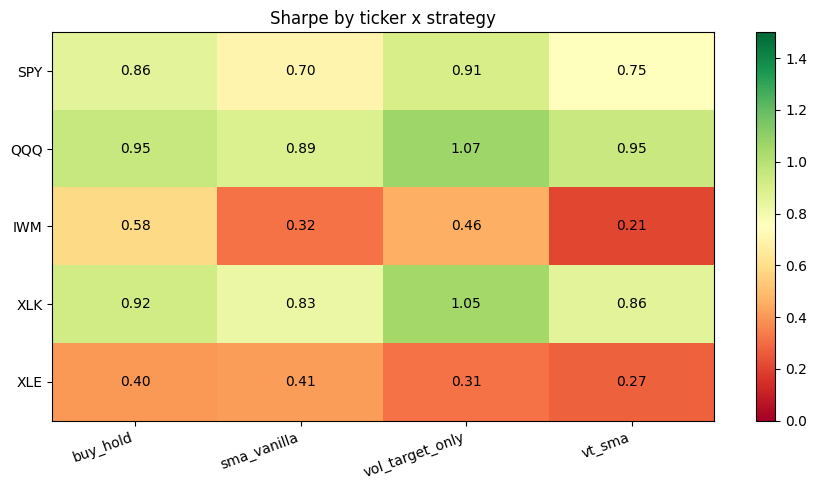

In [5]:
sharpe_pivot = results.pivot(index='ticker', columns='strategy', values='sharpe')[
    ['buy_hold', 'sma_vanilla', 'vol_target_only', 'vt_sma']
].loc[TICKERS]

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(sharpe_pivot.values, cmap='RdYlGn', vmin=0, vmax=1.5, aspect='auto')
ax.set_xticks(range(len(sharpe_pivot.columns)))
ax.set_xticklabels(sharpe_pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(sharpe_pivot.index)))
ax.set_yticklabels(sharpe_pivot.index)
for i in range(sharpe_pivot.shape[0]):
    for j in range(sharpe_pivot.shape[1]):
        ax.text(j, i, f'{sharpe_pivot.values[i, j]:.2f}', ha='center', va='center', color='black', fontsize=10)
ax.set_title('Sharpe by ticker x strategy')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 5. Calmar ratio (CAGR / |Max DD|) — risk-adjusted return

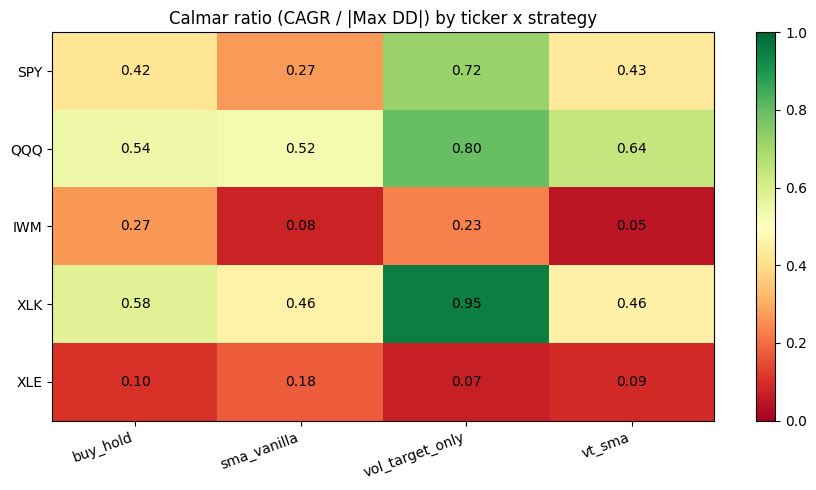

In [6]:
calmar_pivot = results.pivot(index='ticker', columns='strategy', values='calmar')[
    ['buy_hold', 'sma_vanilla', 'vol_target_only', 'vt_sma']
].loc[TICKERS]

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(calmar_pivot.values, cmap='RdYlGn', vmin=0, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(calmar_pivot.columns)))
ax.set_xticklabels(calmar_pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(calmar_pivot.index)))
ax.set_yticklabels(calmar_pivot.index)
for i in range(calmar_pivot.shape[0]):
    for j in range(calmar_pivot.shape[1]):
        ax.text(j, i, f'{calmar_pivot.values[i, j]:.2f}', ha='center', va='center', color='black', fontsize=10)
ax.set_title('Calmar ratio (CAGR / |Max DD|) by ticker x strategy')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 6. Equity curves — SPY, all four strategies

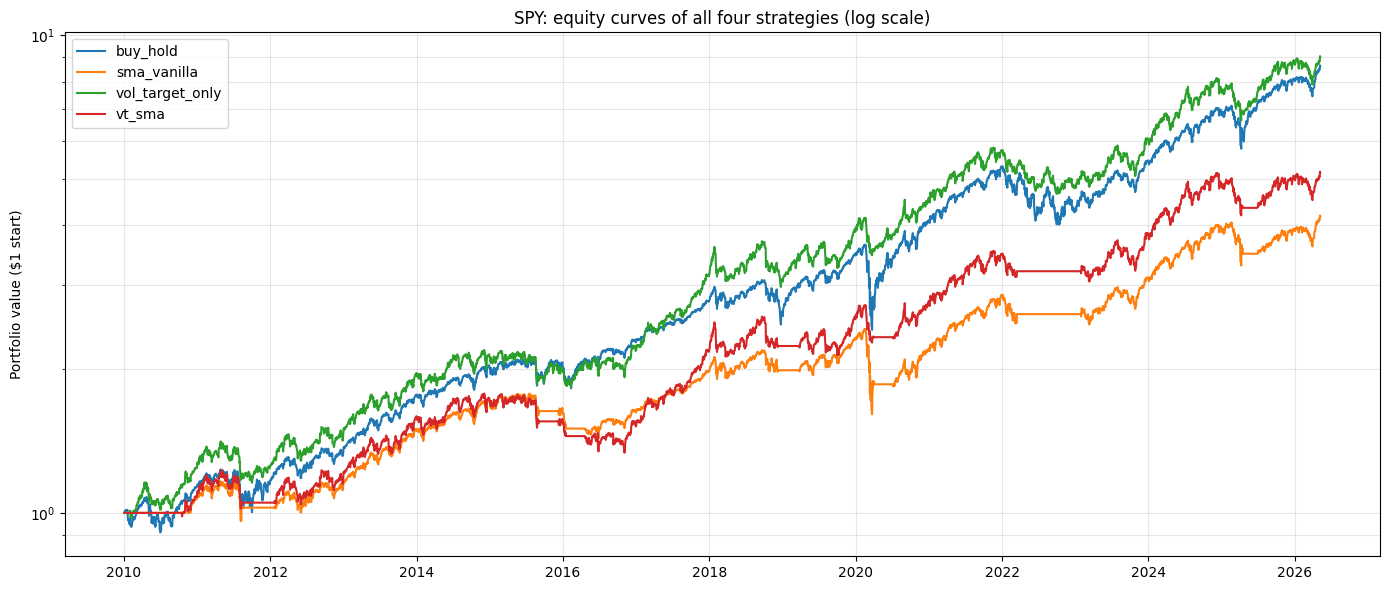

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
for label, eq in equity_curves['SPY'].items():
    ax.plot(eq.index, eq.values, label=label, linewidth=1.5)
ax.set_yscale('log')
ax.set_title('SPY: equity curves of all four strategies (log scale)')
ax.set_ylabel('Portfolio value ($1 start)')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 7. Equity curves — XLE (the regime-change winner)

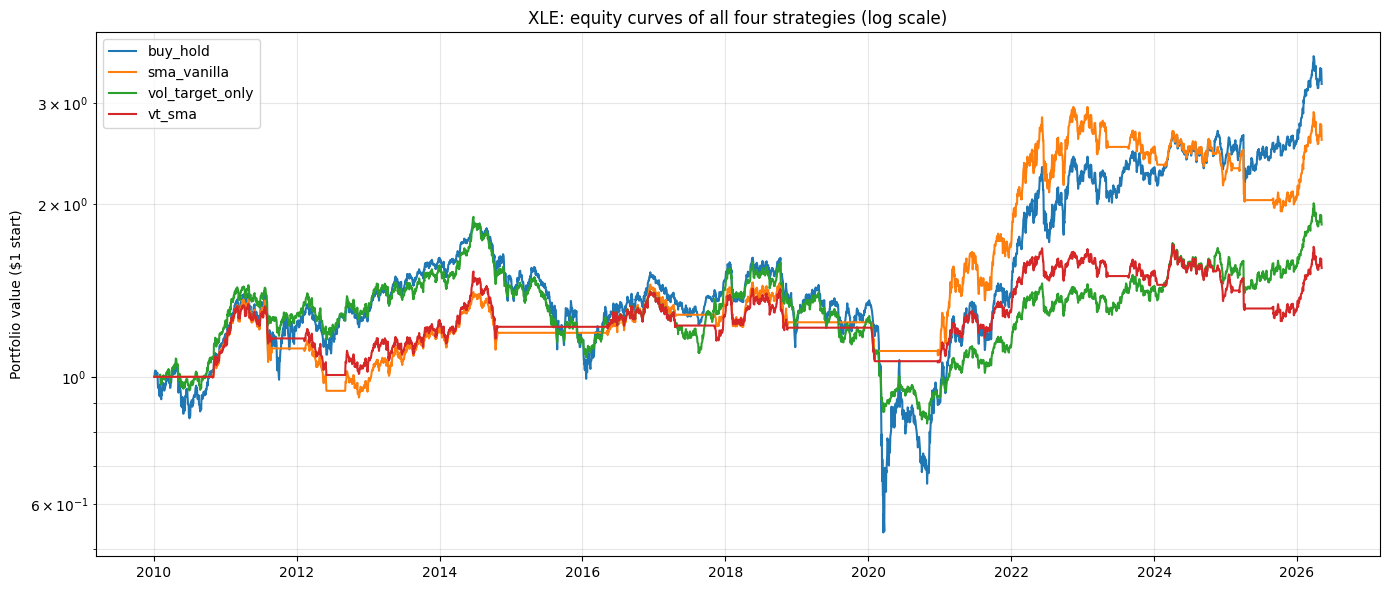

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
for label, eq in equity_curves['XLE'].items():
    ax.plot(eq.index, eq.values, label=label, linewidth=1.5)
ax.set_yscale('log')
ax.set_title('XLE: equity curves of all four strategies (log scale)')
ax.set_ylabel('Portfolio value ($1 start)')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 8. Drawdown comparison: buy-hold vs vt_sma per ticker

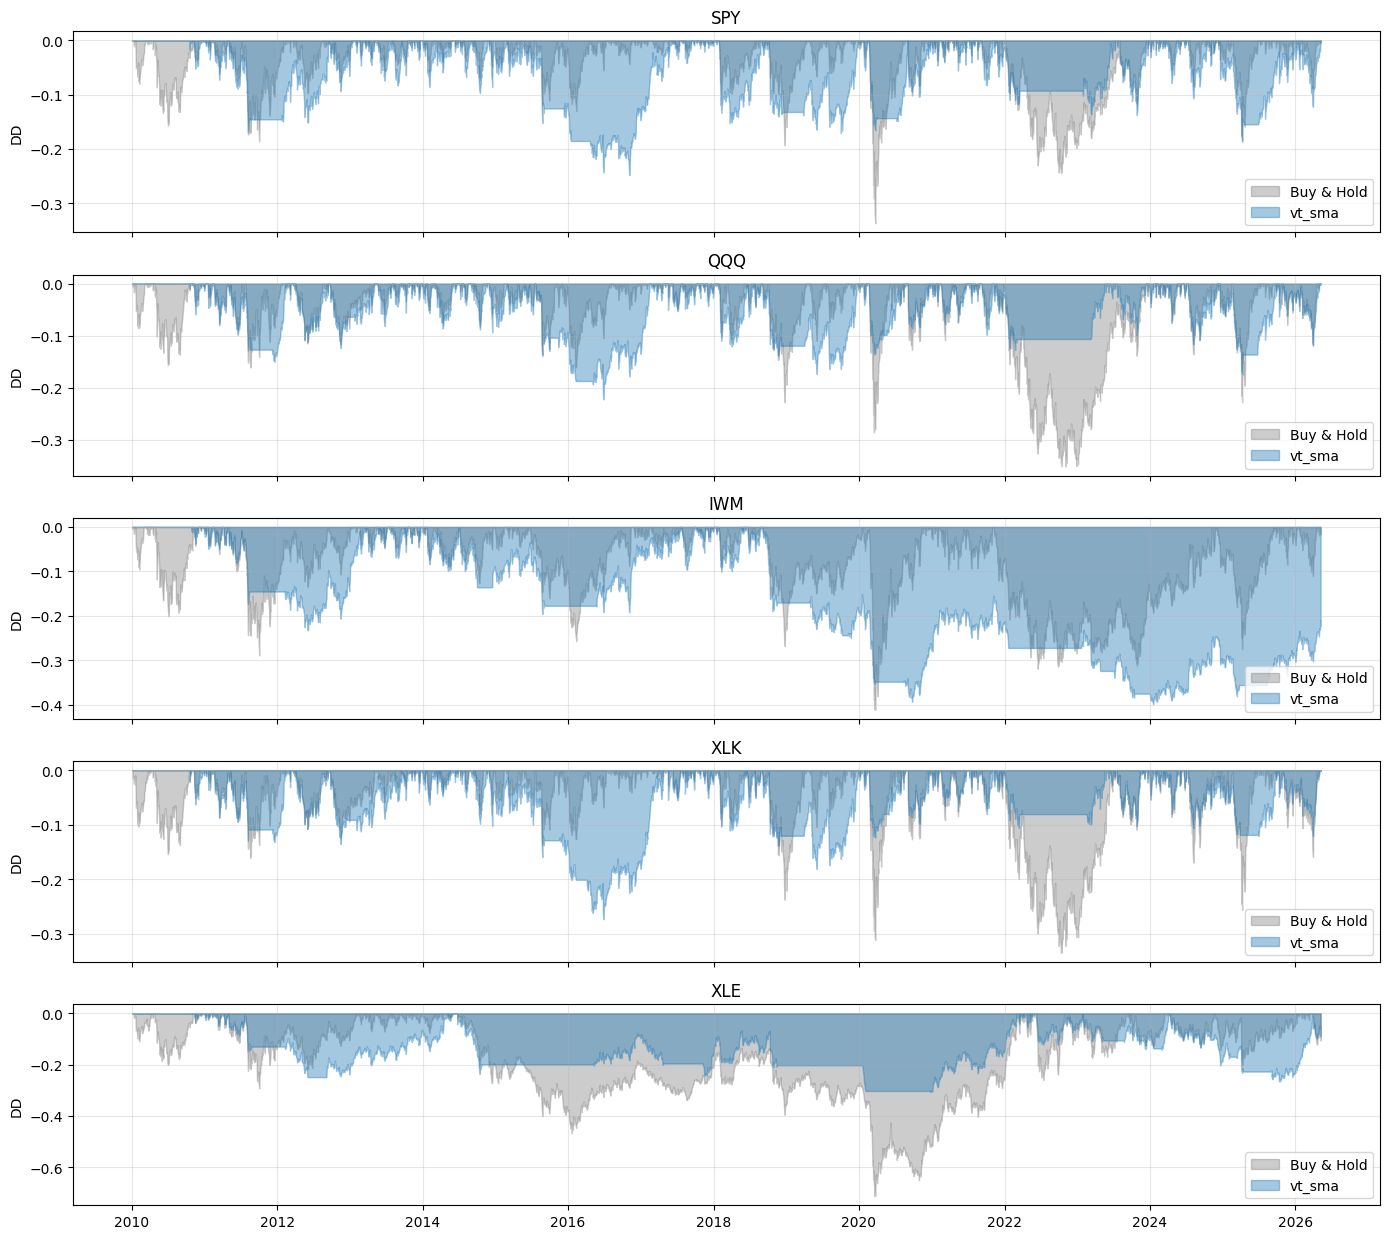

In [9]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 2.5 * len(TICKERS)), sharex=True)
for i, ticker in enumerate(TICKERS):
    eqs = equity_curves[ticker]
    dd_bh = eqs['buy_hold'] / eqs['buy_hold'].cummax() - 1
    dd_vt = eqs['vt_sma'] / eqs['vt_sma'].cummax() - 1
    ax = axes[i]
    ax.fill_between(dd_bh.index, dd_bh, 0, color='gray', alpha=0.4, label='Buy & Hold')
    ax.fill_between(dd_vt.index, dd_vt, 0, color='tab:blue', alpha=0.4, label='vt_sma')
    ax.set_title(ticker)
    ax.set_ylabel('DD')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Honest read

The hypothesis was that sized trend (vt_sma) would beat both vanilla SMA and pure vol-targeting. The data does not support it.

Across SPY, QQQ, IWM, XLK, XLE on this 16-year window, **always-on vol-targeting wins on Sharpe and Calmar on 4 of 5 tickers**. The SMA trend filter throws away too much equity exposure during long bull regimes (notably SPY, QQQ, XLK), and the give-up is not compensated by avoiding bear markets - vol-targeting already trims exposure when realized vol spikes.

Useful negative result: stacking signals does not automatically improve the portfolio. Sometimes a single risk-control mechanism beats a "sized trend" that double-filters. XLE is the only ticker where the trend filter genuinely helps, because the energy regime changes (2014, 2020, 2022) are sharper than vol alone can capture.

Lesson: the next experiment should NOT be "add more layers". It should be diversification across the multi-asset universe with vol-targeting only, or replace the binary SMA filter with a continuous trend score (z-score of returns over a window).

## Caveats

- 5 bps cost is conservative for ETFs but optimistic for individual names.
- Daily rebalance assumed - a real implementation would batch into weekly to cut turnover.
- No financing cost on leverage, no benefit from cash leg yield.
- The vol estimator is naive (20-day std). EWMA / GARCH / Parkinson would change results modestly.
- 16-year window covers 2010s low-vol bull, 2018 chop, 2020 crash, 2022 bear, 2023-2025 rally - broad enough that results are not regime-trivial, narrow enough to miss 2008.

## Next experiments

1. Equal-weight portfolio of vol_target_only across the multi-asset universe - diversification benefit?
2. Continuous trend score (z-score) instead of binary SMA crossover.
3. Add T-bill yield to the cash leg using FRED (`DGS3MO`).
4. EWMA volatility estimator with half-life tuning.
